## Devoir : apprentissage par renforcement dans Grid World

Travail effectué par tjepgskgdpkzeg$k^$zqeg

RAJOUTER QUE LES PREMIERS EPISODES C DE LEXPLORATION SURTOUT ET QU4ENSUITE ON EXPLOITE

## Introduction
On considère un agent évoluant dans un environnement de type Grid World, où il doit atteindre une position cible à partir d’un point de départ. À chaque déplacement, il reçoit une récompense, et doit apprendre à éviter les obstacles comme les murs, les marais ou les falaises, qui rendent la tâche plus risquée.
Pour apprendre à se déplacer efficacement, deux stratégies sont étudiées : Q-Learning et SARSA. Bien qu’elles reposent sur le même principe d’apprentissage, elles diffèrent dans leur manière de prendre en compte l’exploration, ce qui influence directement le comportement de l’agent.
L’objectif est d’observer, à travers plusieurs expériences et configurations, comment ces deux approches apprennent, convergent et réagissent face à des environnements plus ou moins risqués.

Dans un premier temps, il est important de définir le problème étudié. Nous considérons un environnement de type GridWorld, dans lequel un agent se déplace sur une grille à partir d’une position initiale (start) afin d’atteindre une position cible (goal). L’objectif de l’agent est de maximiser la récompense cumulée au cours de ses déplacements, tout en évitant les trajectoires sous-optimales.

Pour résoudre ce problème, nous utilisons deux algorithmes d’apprentissage par renforcement : Q-Learning et SARSA. Ces deux méthodes reposent sur l’apprentissage d’une fonction de valeur d’action, mais se distinguent par leur nature. Le Q-Learning est un algorithme off-policy, qui apprend la politique optimale indépendamment des actions réellement exécutées, tandis que SARSA est un algorithme on-policy, qui apprend en fonction de la politique effectivement suivie par l’agent.

Enfin, nous nous appuyons sur le framework grid_world afin de modéliser l’environnement, gérer les interactions entre l’agent et la grille, et implémenter les différentes stratégies d’apprentissage.

In [80]:
from grid_world import GridWorld, PygameGridWorld
import numpy as np
# check your taskbar for running pygame application GridWorld
game = PygameGridWorld()
grid_world = game.grid_world

#example of using GridWorld, we show the basic functions for 
# state , action, next_state, and reached_goal
state = grid_world.player_position
action = np.random.choice(grid_world.actions)
reached_goal = grid_world.move_player(action)
next_state = grid_world.player_position
print("state, action, next_state, reached_goal")
print(state, action, next_state, reached_goal)

game.main(auto_close=False) # auto_close will close screen automtatically at the end of game.


state, action, next_state, reached_goal
(0, 0) right (1, 0) False


### Agent Q-Learning

Commencons par redéfinir l’algorithme Q-Learning, qui est une méthode d’apprentissage par renforcement qui permet à un agent d’apprendre à prendre des décisions à partir des récompenses qu’il reçoit. Il vise à estimer la fonction de valeur d’action $Q(s,a)$, qui mesure la qualité d’une action $a$ dans un état $s$. Cet algorithme est dit *off-policy*, car il apprend une politique optimale indépendamment de la politique utilisée pour explorer l’environnement. Il repose sur une **Q-table**, qui associe à chaque paire état-action $(s,a)$ une valeur, mise à jour après chaque interaction selon :

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left( R_{t+1} + \gamma \max_a Q(s_{t+1},a) - Q(s_t,a_t) \right)
$$

où $s_t$ est l’état courant, $a_t$ l’action effectuée, $R_{t+1}$ la récompense, $s_{t+1}$ l’état suivant, $\alpha$ le taux d’apprentissage et $\gamma$ le facteur d’actualisation.

### *Fonction *choose_action**

La fonction *choose_action* permet de sélectionner l’action à effectuer à partir d’un état donné. Elle repose sur une stratégie **$\varepsilon$-greedy**, qui établit un compromis entre exploration et exploitation :

- avec une probabilité $\varepsilon$, l’agent choisit une action aléatoire afin d’explorer l’environnement ;
- avec une probabilité $1 - \varepsilon$, il choisit l’action maximisant la valeur $Q(s,a)$ :
$
a = \arg\max_a Q(s,a)
$

Ainsi, une valeur élevée de $\varepsilon$ favorise l’exploration, tandis qu’une valeur faible favorise l’exploitation des connaissances acquises.


### *Fonction *learn**

La fonction *learn* correspond à l’étape d’apprentissage. À partir de l’état courant $s_t$ et de l’action $a_t$, l’agent observe une transition vers un nouvel état $s_{t+1}$ ainsi qu’une récompense $R_{t+1}$.
Une nouvelle estimation, appelée **cible**, est alors calculée :

$
\text{cible} = R_{t+1} + \gamma \max_a Q(s_{t+1},a)
$

La valeur $Q(s_t,a_t)$ est ensuite mise à jour en corrigeant l’ancienne estimation :
$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left( \text{cible} - Q(s_t,a_t) \right)
$

Cette mise à jour permet d’ajuster progressivement la Q-table en fonction des nouvelles observations. Au fil des itérations, l’agent améliore ses estimations et converge vers une politique optimale.

In [82]:
import random
import numpy as np

class QLearningAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)  # your implementation
        else:
            q_values = [self.get_q_value(state, action) for action in self.actions]
            max_q_value = q_values.index(max(q_values)) # on prend la valeur la plus elevé de la qtable pour l'instant s
            return self.actions[max_q_value]

    def learn(self, state, action, reward, next_state):
        current_q_value = self.get_q_value(state, action)
        next_q_values = [self.get_q_value(next_state, next_action) for next_action in self.actions]
        max_next_q_value = max(next_q_values)
        new_q_value = current_q_value + self.alpha * (reward + self.gamma * max_next_q_value - current_q_value) 
        self.update_q_value(state, action, new_q_value)

### Agent SARSA

L’algorithme SARSA est une méthode d’apprentissage par renforcement qui permet à un agent d’apprendre une politique à partir des actions qu’il effectue réellement. Contrairement au Q-Learning, il s’agit d’un algorithme *on-policy*, ce qui signifie qu’il apprend la valeur d’une politique en suivant exactement cette politique.

Le principe repose sur l’utilisation d’une **Q-table**, qui associe à chaque paire état-action $(s,a)$ une valeur. La mise à jour prend en compte l’action réellement choisie dans l’état suivant, selon la règle :

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left( R_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right)
$$

où $s_t$ est l’état courant, $a_t$ l’action effectuée, $R_{t+1}$ la récompense obtenue, $s_{t+1}$ l’état suivant, $a_{t+1}$ l’action réellement choisie dans cet état, $\alpha$ le taux d’apprentissage et $\gamma$ le facteur d’actualisation.

La fonction *choose_action* repose sur une stratégie $\varepsilon$-greedy : avec une probabilité $\varepsilon$, l’agent choisit une action aléatoire (exploration), sinon il sélectionne l’action maximisant $Q(s,a)$ (exploitation).

La fonction *learn* met à jour la Q-table en utilisant l’action réellement choisie $a_{t+1}$ dans l’état suivant, ce qui permet à l’agent d’apprendre en tenant compte de son comportement effectif. Cette particularité rend SARSA plus prudent, notamment dans des environnements comportant des risques, car il intègre directement les conséquences de l’exploration dans son apprentissage.

In [83]:
# Create a SARSA agent class
class SarsaAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)  # your implementation
        else:
            q_values = [self.get_q_value(state, action) for action in self.actions]
            max_q_value = q_values.index(max(q_values))  # your implementation
            return self.actions[max_q_value]

    def learn(self, state, action, reward, next_state, next_action):
        current_q_value = self.get_q_value(state, action)
        next_q_value = self.get_q_value(next_state, next_action)
        new_q_value = current_q_value + self.alpha * (reward + self.gamma * next_q_value - current_q_value)
        self.update_q_value(state, action, new_q_value)

### Différence théorique entre Q-Learning et SARSA

La différence fondamentale entre Q-Learning et SARSA repose sur leur nature *off-policy* et *on-policy*, ce qui influence directement leur manière de gérer le compromis entre **exploration** et **exploitation**.
- Q-Learning apprend une politique optimale théorique en supposant une exploitation parfaite du futur ;
- SARSA apprend une politique réaliste en intégrant explicitement le compromis exploration/exploitation.

En pratique, cela se traduit souvent par des comportements différents : Q-Learning converge plus rapidement vers une solution optimale, tandis que SARSA produit des trajectoires plus sûres dans des environnements incertains ou risqués.

<div style="color:DarkBlue">

### Dilemme central : exploration vs exploitation

Contrairement à l’apprentissage supervisé, les données en apprentissage par renforcement ne sont pas fixes : elles dépendent directement du comportement de l’agent. Ainsi, l’agent doit en permanence arbitrer entre deux objectifs opposés :

- **Exploration** : découvrir de nouvelles actions afin d’améliorer sa connaissance de l’environnement et potentiellement trouver de meilleures stratégies.
- **Exploitation** : utiliser les connaissances actuelles pour maximiser immédiatement les récompenses.

Dans notre Tp, et avec ces algorithmes on est face à un réel trade of entre exploration et exploitation.


</div>

### **Implémentation et simplifications**

On passe maintenant à l’implémentation des deux algorithmes en s’appuyant sur une définition simple de la fonction de récompense. L’environnement est conçu pour encourager l’agent à atteindre l’objectif le plus rapidement possible.
- $r = +100$ si l’objectif est atteint  
- $r = -1$ sinon  
Ce choix permet de fortement valoriser l’état terminal tout en pénalisant chaque étape intermédiaire, incitant ainsi l’agent à minimiser le nombre de déplacements avant d’atteindre la cible.

In [84]:
def get_intended_position(state, action, grid_world):# on prend l'origine en haut a gauche p
    x, y = state
    if action == "up":
        y = max(0, y - 1)
    elif action == "down":
        y = min(grid_world.height - 1, y + 1)
    elif action == "left":
        x = max(0, x - 1)
    elif action == "right":
        x = min(grid_world.width - 1, x + 1)
    return (x, y)


def get_reward(grid_world, reached_goal, intended_position, reward_goal=100, reward_default=-1,
               reward_marsh=-10, reward_cliff=-100):
    if reached_goal:
        return reward_goal
    if intended_position in getattr(grid_world, "cliff_positions", []):
        return reward_cliff
    if intended_position in getattr(grid_world, "marsh_positions", []):
        return reward_marsh
    return reward_default




def train_q_learning_agent(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    rewards = 0

    while not grid_world.is_game_over() and steps < max_steps:
        state = grid_world.player_position
        action = agent.choose_action(state)

        intended_position = get_intended_position(state, action, grid_world)
        reached_goal = grid_world.move_player(action)
        next_state = grid_world.player_position

        reward = get_reward(grid_world, reached_goal, intended_position, **rewards_config)

        agent.learn(state, action, reward, next_state)

        steps += 1
        rewards += reward

    return steps, rewards


def train_sarsa_agent(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    rewards = 0

    state = grid_world.player_position
    action = agent.choose_action(state)

    while not grid_world.is_game_over() and steps < max_steps:  #game over fonction de l'environement 
        intended_position = get_intended_position(state, action, grid_world)

        reached_goal = grid_world.move_player(action)
        next_state = grid_world.player_position

        reward = get_reward(grid_world, reached_goal, intended_position, **rewards_config)

        next_action = agent.choose_action(next_state)

        agent.learn(state, action, reward, next_state, next_action)

        state = next_state
        action = next_action

        steps += 1
        rewards += reward

    return steps, rewards

#### Fonction ExperimentAgent

La fonction `ExperimentAgent` permet d’entraîner un agent (Q-Learning ou SARSA) sur plusieurs épisodes dans un environnement GridWorld.

À chaque épisode :
- on réinitialise l’état initial,
- on entraîne l’agent avec `train_q_learning_agent` ou `train_sarsa_agent`,
- on enregistre le nombre de pas et la récompense totale.

Le paramètre $\varepsilon$ diminue progressivement :
$
\varepsilon \leftarrow \max(0.1, \varepsilon - \text{decay})
$
ce qui réduit l’exploration au profit de l’exploitation.

La Q-table est sauvegardée régulièrement avec `pickle`.
La fonction retourne :
- `steps_per_episode` (efficacité),
- `reward_per_episode` (performance).

Rappel : un **épisode** correspond à une tentative complète de l’agent, allant de l’état initial jusqu’à l’atteinte de l’objectif (ou une condition d’arrêt); elle correspond à 1000 tentatives successives d'apprentissage sur un même Q-table. Un **step** correspond à une action individuelle effectuée par l’agent à un instant donné. Ainsi, le nombre d’épisodes contrôle le nombre total d’expériences d’apprentissage, tandis que le nombre de steps limite la durée maximale de chaque tentative.

In [85]:
def ExperimentAgent(your_agent_class_object,
                    epsilon=0.9, epsilon_decay=0.15,
                    num_episodes=300, alpha=0.1, gamma=0.99,
                    grid_world=None, max_steps=110, rewards_config=None, auto_replay=False, ticks=50):
    if grid_world is None:
        grid_world = GridWorld(10, 10,
                        wall_positions=[ (1, 1), (2, 2), (3, 3), (4, 4),
                                            (3, 2), (3, 1),
                                            (5, 5), (5,0),
                                            (6, 1), (6,2), (6,3),
                                            (8, 9), (8, 8),  (8, 7),(8, 6),
                                            (8, 5), (8, 4),(8, 3),(8, 2),],
                        goal_positions=[(9,9)])
    YourAgentClass = your_agent_class_object
    agent = YourAgentClass(grid_world, alpha=alpha,
                            gamma=gamma, epsilon=epsilon
                            )

    steps_per_episode = []
    reward_per_episode = []
    for episode in range(num_episodes):
        grid_world.player_position = grid_world.init_player_position
        if agent.__class__.__name__ == "QLearningAgent":
            steps, rewards = train_q_learning_agent(agent, grid_world, max_steps, rewards_config)
        elif agent.__class__.__name__ == "SarsaAgent":
            steps, rewards = train_sarsa_agent(agent, grid_world, max_steps, rewards_config)
        else:
            raise ValueError(f"Agent non supporté : {agent.__class__.__name__}")

        steps_per_episode.append(steps)
        reward_per_episode.append(rewards)

        # enregistrer les politiques apprises dans des fichiers pickle
        if episode % 50 == 0:
            agent.epsilon = max(0.1, agent.epsilon - epsilon_decay)
            # Enregistrer la politique apprise
            with open(f"learned_policy_{YourAgentClass.__name__}_episode_{episode}.pkl", "wb") as f:
                pickle.dump(agent.q_table, f)

    # Sauvegarde aussi la politique finale pour faciliter l'analyse.
    with open(f"learned_policy_{YourAgentClass.__name__}_episode_{num_episodes}.pkl", "wb") as f:
        pickle.dump(agent.q_table, f)

    print(f"{YourAgentClass.__name__} entraîné pendant {num_episodes} épisodes")

    return steps_per_episode, reward_per_episode, agent

In [86]:
import pickle
steps_per_episode_QLearning, reward_per_episode_Q, q_learning_agent = ExperimentAgent(QLearningAgent, num_episodes=1000 , max_steps=500)

steps_per_episode_Sarsa, reward_per_episode_Sarsa, sarsa_agent = ExperimentAgent(SarsaAgent, num_episodes=1000 , max_steps=500)

QLearningAgent entraîné pendant 1000 épisodes
SarsaAgent entraîné pendant 1000 épisodes


In [121]:
import matplotlib.pyplot as plt

def plot_comparison(steps_per_episode_QLearning, reward_per_episode_QLearning,
                    steps_per_episode_Sarsa, reward_per_episode_Sarsa):

    # Plot the graph of steps per episode
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(steps_per_episode_QLearning, color='blue', alpha=0.7)
    ax1.plot(steps_per_episode_Sarsa, color='orange', alpha=0.7)
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Steps')
    ax1.legend(['QLearningAgent' ,'SarsaAgent'])
    ax1.set_title(f'Total Steps per Episode')
    ax1.set_yscale('log')

    # Plot the graph of steps per episode
    ax2.plot(reward_per_episode_QLearning, color='blue', alpha=0.7)
    ax2.plot(reward_per_episode_Sarsa, color='orange', alpha=0.7)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Cumulative reward')
    ax2.legend(['QLearningAgent' ,'SarsaAgent'])
    ax2.set_title(f'Cumulative Rewards per Episode')
    plt.show()

Au début, les premiers épisodes sont consacrés à l’exploration afin de découvrir l’environnement et collecter de l’information, puis progressivement l’agent passe à une phase d’exploitation où il utilise ce qu’il a appris pour maximiser la récompense.

Les résultats montrent que Q-Learning converge plus rapidement que SARSA, avec une diminution plus rapide du nombre d’étapes et une augmentation plus précoce des récompenses. Cela s’explique par son caractère off-policy : lors de la mise à jour, il utilise systématiquement la meilleure action possible via $\max_a Q(s,a)$, indépendamment de la politique réellement suivie. Cette approche optimiste accélère la propagation des valeurs élevées, mais introduit un biais d’optimisme, souvent appelé overestimation bias. Ce biais peut entraîner une variance plus élevée dans les estimations et rendre l’apprentissage moins stable, en particulier dans des environnements stochastiques ou comportant des pénalités importantes.

À l’inverse, SARSA adopte une approche on-policy. La mise à jour repose sur l’action réellement choisie :
$
Q(s,a) \leftarrow Q(s,a) + \alpha \big(r + \gamma Q(s',a') - Q(s,a)\big)
$
ce qui intègre directement l’exploration dans l’apprentissage. En tenant compte du comportement réel de l’agent, SARSA réduit le biais d’optimisme et présente généralement une variance plus faible. L’apprentissage est donc plus progressif, mais aussi plus stable et plus robuste face aux incertitudes.

D’un point de vue théorique, Q-Learning privilégie la rapidité de convergence au prix d’une plus grande variance et d’un risque de surestimation, tandis que SARSA offre un compromis biais-variance plus équilibré. En conséquence, Q-Learning est souvent plus efficace dans des environnements simples ou déterministes, alors que SARSA est mieux adapté aux environnements risqués ou bruités.

<div style="color:DarkGreen"> En résumé, Q-Learning converge plus vite mais avec une variance plus élevée, tandis que SARSA converge plus lentement mais de manière plus stable et prudente. <div>

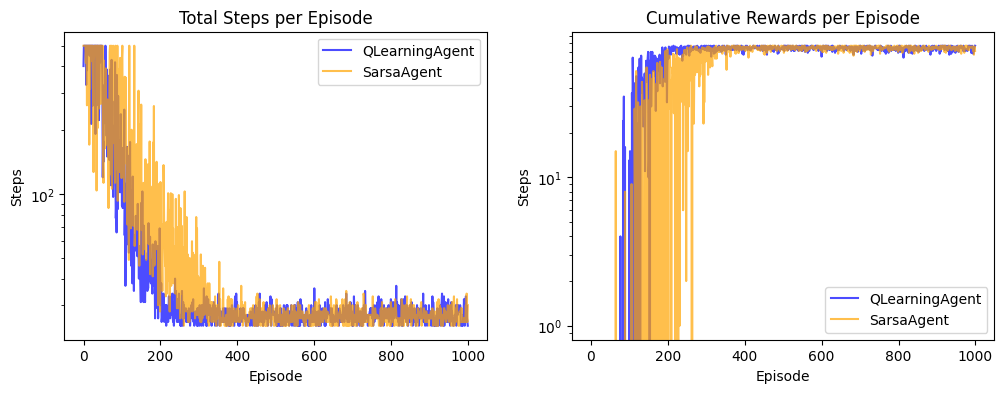

In [88]:
plot_comparison(
    steps_per_episode_QLearning, reward_per_episode_Q,
    steps_per_episode_Sarsa, reward_per_episode_Sarsa
)

In [89]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_q_values_and_action_table(q_table, agent_name, grid_size=(10, 10)):
    action_arrow = {"left":'←', "right":'→', "up":'↑', "down":'↓', }

    # Assuming a 10x10 grid as per the initial code
    mat = np.zeros(grid_size) - np.inf
    directions = np.zeros(grid_size, dtype=str)

    # Process QLearning_table for visualization
    for ((x, y), action), value in q_table.items():
        if mat[(y, x)] < value:  # Assuming you want to display the max Q value for each position
            mat[y, x] = value  
            directions[y, x] = action_arrow[action] 

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))
    mat[~np.isfinite(mat)] = 0
    vmin, vmax = np.min(mat), np.max(mat)
    # Q_values heatmap
    sns.heatmap(mat, annot=mat, fmt=".0f", cmap="vlag", ax=ax[0], annot_kws={"fontsize":12})
    ax[0].set_title(f"{agent_name} Q Values Table")
    ax[0].collections[0].set_clim(vmin,vmax)   

    # Action heatmap
    sns.heatmap(mat, annot=directions, fmt='', cmap="vlag", ax=ax[1], annot_kws={"fontsize":28})
    ax[1].set_title(f"{agent_name} Action Table")
    ax[1].collections[0].set_clim(vmin,vmax)   

    plt.show()

La carte des valeurs montre une augmentation progressive des Q-values à mesure que l’on se rapproche de l’objectif, ce qui indique que l’agent a correctement appris la qualité des états. Les positions proches du but ont des valeurs plus élevées, car elles permettent d’obtenir une récompense importante avec moins de pénalités.

La politique associée (flèches) oriente globalement l’agent vers l’objectif. Quelques incohérences apparaissent dans les zones éloignées, ce qui s’explique par une exploration encore présente et un nombre d’épisodes limité. Malgré cela, la stratégie reste cohérente.
L’apprentissage est incrémental : à chaque étape, la valeur est mise à jour selon Q(s,a)←Q(s,a)+α(r+γmaxaQ(s′,a)−Q(s,a)) ce qui permet d’ajuster progressivement les estimations.
Les valeurs élevées correspondent aux actions les plus avantageuses et font émerger implicitement un chemin optimal dans la grille.


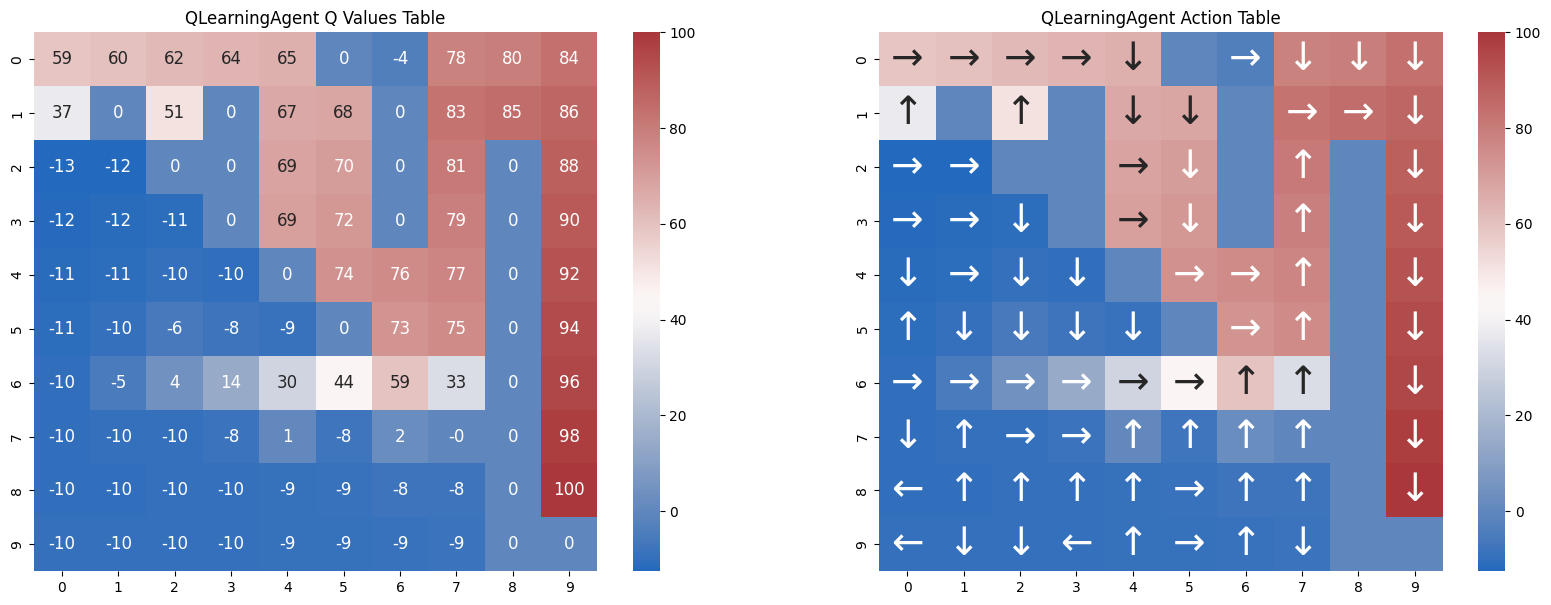

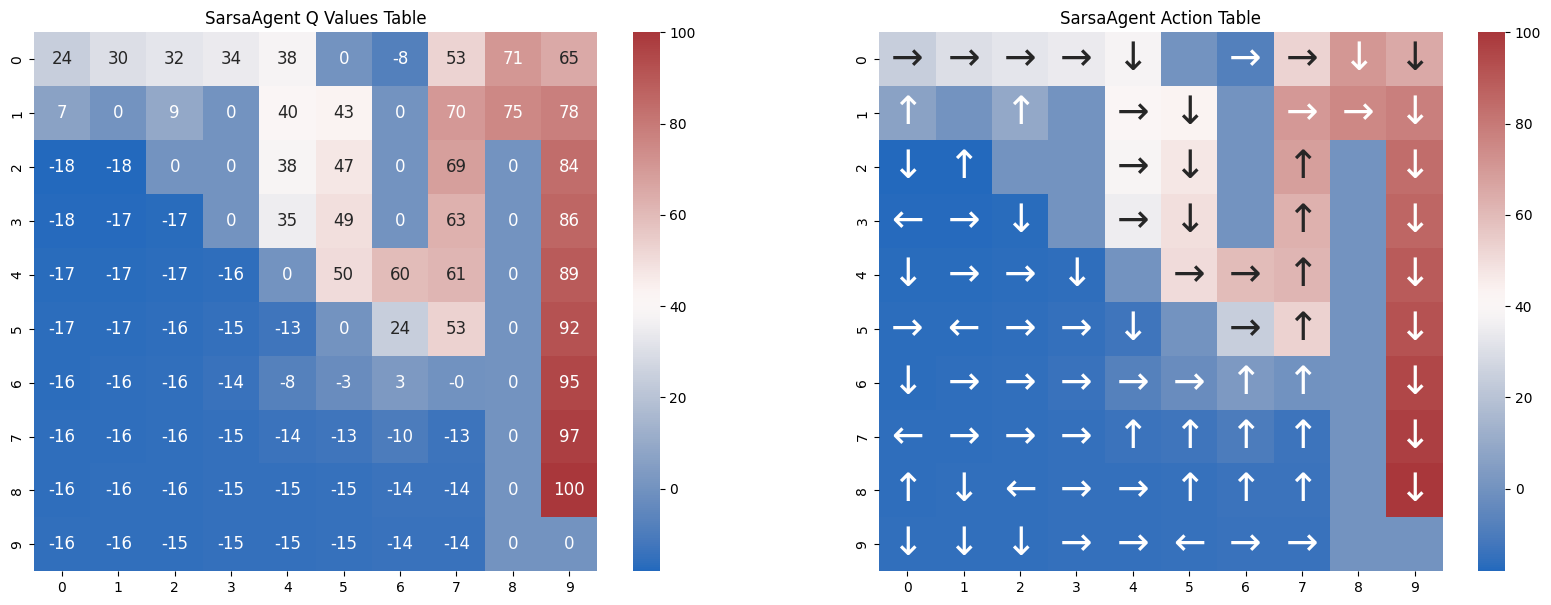

In [91]:
plot_q_values_and_action_table(q_learning_agent.q_table, 'QLearningAgent')
plot_q_values_and_action_table(sarsa_agent.q_table, 'SarsaAgent')


In [118]:
steps_per_episode_QLearning, reward_per_episode_Q, q_learning_agent = ExperimentAgent(QLearningAgent, num_episodes=100 , max_steps=50)
steps_per_episode_Sarsa, reward_per_episode_Sarsa, sarsa_agent = ExperimentAgent(SarsaAgent, num_episodes=100 , max_steps=50)

QLearningAgent entraîné pendant 100 épisodes
SarsaAgent entraîné pendant 100 épisodes


La réduction du nombre d’épisodes et du nombre maximal de pas limite la capacité d’exploration et d’apprentissage de l’agent, ce qui conduit à une Q-table moins précise et à une politique sous-optimale, faute de convergence suffisante.


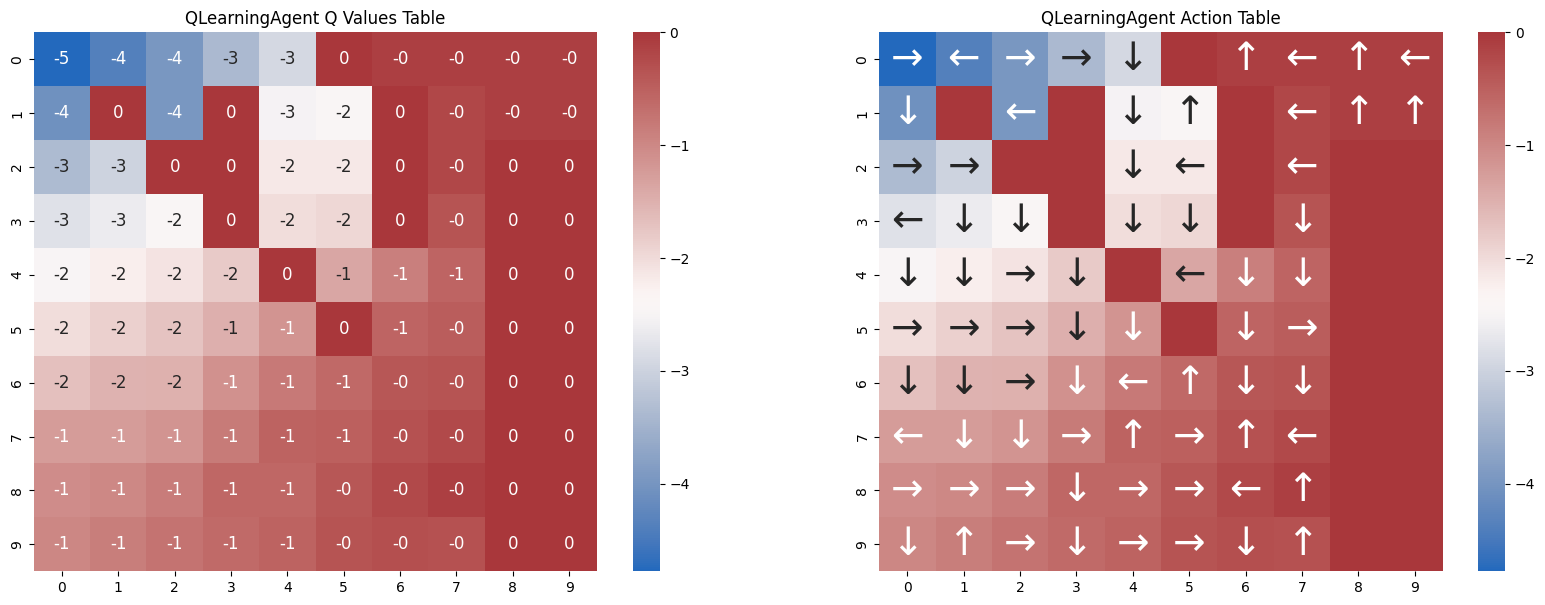

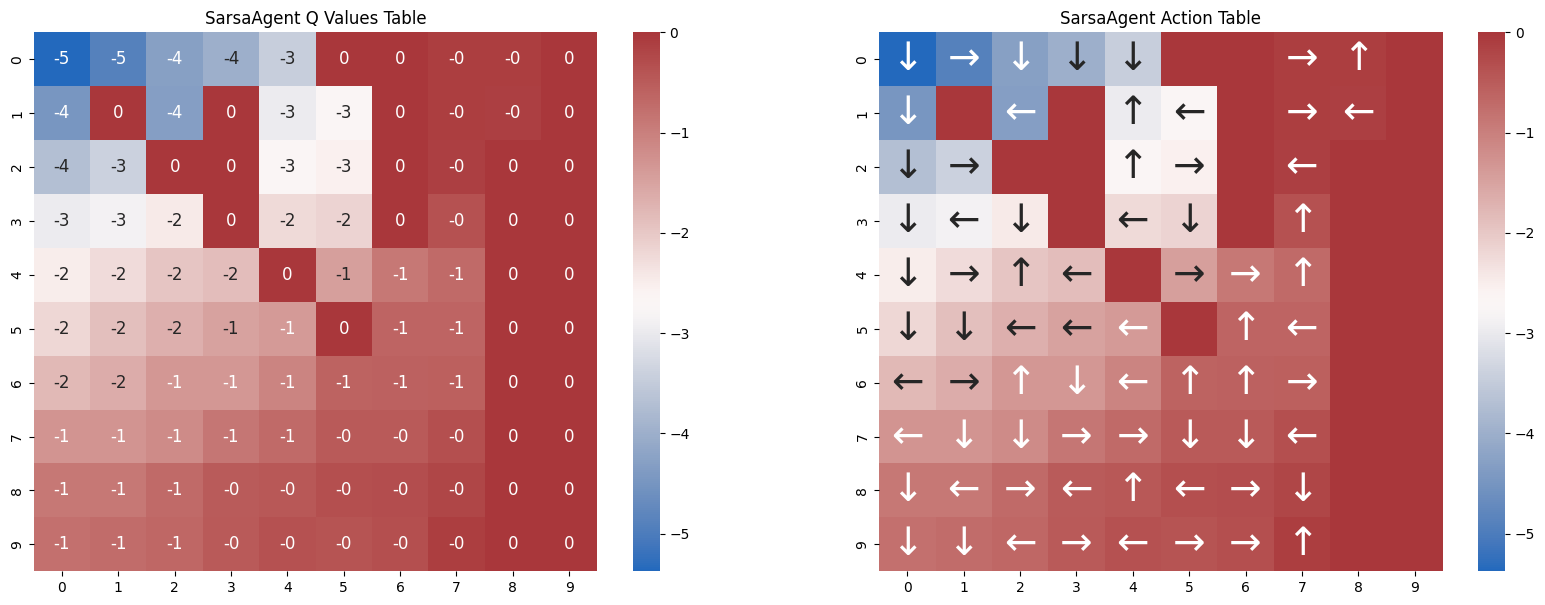

In [119]:
plot_q_values_and_action_table(q_learning_agent.q_table, 'QLearningAgent')
plot_q_values_and_action_table(sarsa_agent.q_table, 'SarsaAgent')


On peut utiliser le wrapper `SimulationGridWorld`, qui repose sur l’algorithme Q-Learning, afin de visualiser le comportement de l’agent. La visualisation est activée uniquement lorsque le paramètre `auto_replay` est défini à `True`, ce qui permet d’observer les trajectoires apprises dans l’environnement.

In [92]:
from grid_world import SimulationGridWorld
a=SimulationGridWorld(QLearningAgent,
                    params={"gamma":0.99,
                            "epsilon":0.1, 
                            "alpha":0.1},
                    episode=1000, 
                    grid_world=None,
                    auto_replay=False, 
                    ticks=50) # ticks is the frames per seconds

On cherche également à vérifier la convergence de l’agent. Contrairement au deep learning classique, où la convergence se mesure souvent via une fonction de perte, ici un agent est considéré comme convergé lorsqu’il adopte un comportement stable dans l’environnement. Concrètement, cela signifie qu’il atteint l’objectif sans hésitation, en suivant un chemin quasi identique à chaque épisode. Dans ce cas, l’exploration devient inutile (ε n’a plus d’impact) et la Q-table se stabilise, avec des valeurs qui n’évoluent presque plus.

Un indicateur important est le nombre de pas par épisode. On observe généralement une diminution progressive du nombre de steps jusqu’à atteindre un plateau, par exemple autour de 25 pas, ce qui indique que l’agent a appris un trajet efficace. La récompense cumulée permet également de vérifier la convergence : si elle devient stable et élevée (par exemple autour de 73 dans notre cas), cela confirme que l’agent adopte une stratégie cohérente et performante.

Ainsi, converger signifie apprendre un chemin stable vers l’objectif. Un bon modèle se caractérise donc par un chemin court, une récompense élevée et des performances stables dans le temps. Toutefois, il est important de distinguer convergence et optimalité. Un agent peut converger vers une stratégie sous-optimale, par exemple en restant bloqué dans un minimum local ou en évitant des zones risquées qui pourraient pourtant conduire à une solution plus efficace.

Nb :  la fonction SimulationGridWorld ne permet pas de récupérer les métriques d’apprentissage telles que le nombre de pas par épisode ou les récompenses cumulées. Elle est uniquement destinée à la visualisation du comportement de l’agent dans l’environnement.

Ainsi, pour analyser les performances et vérifier la convergence, il est nécessaire de réutiliser la fonction ExperimentAgent définie précédemment. Cette dernière permet d’entraîner l’agent sur plusieurs épisodes tout en enregistrant les indicateurs essentiels (steps et rewards), indispensables pour une évaluation quantitative.


In [93]:
print(steps_per_episode_QLearning)
print(reward_per_episode_Q)

[260, 500, 500, 500, 500, 500, 500, 500, 500, 457, 500, 336, 500, 500, 470, 500, 500, 500, 385, 386, 500, 243, 500, 500, 313, 500, 500, 500, 500, 332, 155, 500, 500, 500, 455, 372, 164, 387, 500, 368, 349, 274, 500, 263, 229, 500, 340, 446, 122, 496, 126, 82, 163, 248, 302, 428, 228, 500, 152, 197, 357, 179, 265, 257, 93, 377, 83, 164, 196, 130, 500, 195, 181, 52, 138, 189, 90, 175, 232, 111, 146, 363, 50, 134, 238, 197, 97, 304, 98, 138, 192, 97, 234, 49, 189, 101, 110, 124, 75, 80, 67, 61, 76, 70, 75, 35, 135, 100, 144, 114, 38, 127, 62, 31, 67, 78, 63, 84, 145, 86, 86, 51, 43, 56, 55, 107, 76, 109, 39, 47, 147, 41, 109, 58, 62, 60, 73, 36, 62, 43, 60, 86, 103, 61, 46, 76, 62, 50, 123, 51, 57, 41, 55, 53, 32, 54, 35, 39, 31, 42, 50, 105, 38, 49, 32, 52, 40, 65, 37, 56, 66, 39, 44, 38, 39, 38, 49, 45, 36, 40, 30, 41, 32, 57, 29, 47, 41, 33, 40, 37, 43, 31, 46, 35, 32, 35, 40, 42, 28, 35, 39, 36, 26, 36, 31, 28, 26, 29, 33, 30, 28, 24, 27, 30, 28, 25, 30, 26, 31, 24, 28, 27, 26, 28, 29

On fait l'équivalent avec le modèle Sarsa, (on peut relever que le temps d'execution, est à juste titre plus long).

In [94]:
from grid_world import SimulationGridWorld
SimulationGridWorld(SarsaAgent,
                    params={"gamma":0.99,
                            "epsilon":0.1, 
                            "alpha":0.1},
                    episode=1000, 
                    grid_world=None,
                    auto_replay=False, 
                    ticks=50) # ticks is the frames per seconds

In [95]:
print(steps_per_episode_Sarsa)
print(reward_per_episode_Sarsa)

[500, 216, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 449, 500, 500, 500, 500, 500, 410, 353, 500, 500, 500, 500, 500, 500, 500, 500, 462, 500, 443, 500, 500, 394, 500, 275, 335, 382, 209, 322, 268, 176, 500, 500, 362, 500, 122, 500, 208, 500, 500, 168, 271, 120, 432, 483, 500, 430, 173, 69, 500, 131, 500, 453, 417, 233, 440, 297, 500, 214, 125, 342, 194, 265, 500, 85, 209, 79, 438, 171, 334, 204, 124, 91, 471, 500, 291, 276, 132, 129, 500, 188, 319, 189, 322, 108, 381, 158, 202, 253, 117, 216, 70, 110, 474, 153, 138, 90, 108, 303, 94, 191, 88, 237, 191, 54, 162, 140, 70, 199, 87, 407, 149, 168, 199, 175, 79, 105, 149, 51, 49, 199, 224, 85, 101, 280, 50, 106, 107, 152, 61, 197, 90, 78, 167, 64, 161, 78, 139, 133, 171, 110, 40, 65, 147, 172, 73, 58, 56, 54, 57, 85, 84, 117, 57, 268, 162, 75, 55, 60, 58, 67, 57, 139, 96, 36, 76, 80, 41, 88, 80, 46, 165, 104, 35, 105, 46, 122, 48, 54, 83, 48, 74, 188, 87, 61, 62, 121, 49, 45, 104, 26, 101, 43, 92, 52, 84, 72, 38, 38, 57, 49, 3

In [96]:
print(len(steps_per_episode_QLearning))
print(len(steps_per_episode_Sarsa))

1000
1000


## Analyse de la convergence : Q-Learning vs SARSA

On observe une diminution progressive du nombre de pas pour les deux agents, ce qui montre qu’ils apprennent à atteindre l’objectif plus efficacement.

- **Q-Learning** converge rapidement : forte baisse des steps au début puis stabilisation.  
- **SARSA** converge plus lentement mais atteint un niveau similaire.

Cette différence s’explique en grande partie par le compromis **exploration / exploitation** 
Avec une stratégie **ε-greedy** :
- avec probabilité **ε** → exploration (action aléatoire)  
- avec probabilité **1 − ε** → exploitation (meilleure action connue)

#### Impact sur Q-Learning vs SARSA

- **Q-Learning (off-policy)** met à jour ses valeurs en supposant toujours une **exploitation maximale** (meilleure action future).  
  → Il apprend plus vite mais peut être **trop optimiste**.

- **SARSA (on-policy)** prend en compte l’action réellement choisie (donc incluant l’exploration liée à ε).  
  → Il apprend plus lentement mais de façon **plus réaliste et stable**.

#### Récompense cumulée

- Augmente progressivement puis se stabilise pour les deux agents.  
- Q-Learning atteint plus vite de fortes récompenses.  
- SARSA est plus lent mais converge vers des performances similaires.

Les deux agents trouvent une politique efficace (peu de steps, récompense élevée), mais avec des dynamiques d’apprentissage différentes liées à la gestion du compromis exploration/exploitation.

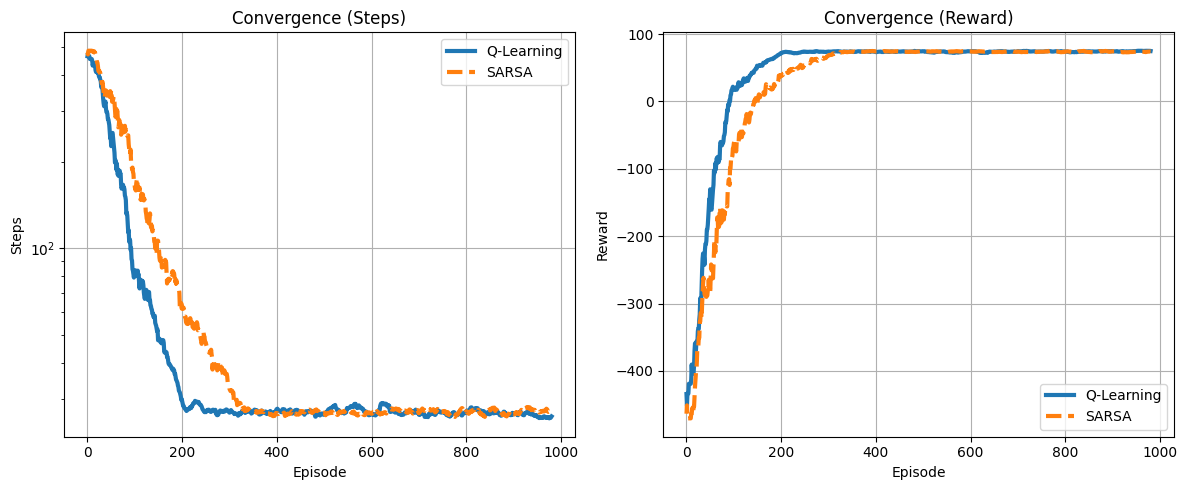

In [97]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, w=20):
    x = np.asarray(x)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

win = 20

# ===== MOYENNES =====
 
ma_steps_ql = moving_average(steps_per_episode_QLearning, win)
ma_steps_sa = moving_average(steps_per_episode_Sarsa, win)

ma_rewards_ql = moving_average(reward_per_episode_Q, win)
ma_rewards_sa = moving_average(reward_per_episode_Sarsa, win)

# ===== FIGURE =====
plt.figure(figsize=(12,5))

# ---- STEPS ----
plt.subplot(1,2,1)
plt.plot(ma_steps_ql, linewidth=3, label="Q-Learning")
plt.plot(ma_steps_sa, linewidth=3, linestyle="--", label="SARSA")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Convergence (Steps)")
plt.yscale("log")  # IMPORTANT pour séparer les courbes
plt.legend()
plt.grid()

# ---- REWARDS ----
plt.subplot(1,2,2)
plt.plot(ma_rewards_ql, linewidth=3, label="Q-Learning")
plt.plot(ma_rewards_sa, linewidth=3, linestyle="--", label="SARSA")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Convergence (Reward)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Conclusion

Dans cette première partie, les résultats montrent que Q-Learning converge plus rapidement que SARSA grâce à son caractère off-policy, qui permet une propagation plus rapide des valeurs optimales. Cependant, cette approche repose sur une hypothèse optimiste du comportement futur, ce qui peut introduire une certaine instabilité.

À l’inverse, SARSA apprend de manière plus progressive en tenant compte des actions réellement exécutées, incluant l’exploration. Cela conduit à un comportement plus prudent et souvent plus stable, bien que plus lent à converger.

Ces différences illustrent l’impact du compromis exploration/exploitation sur l’apprentissage et mettent en évidence les avantages et limites de chaque approche dans un environnement simple comme GridWorld.


---


## Partie 2 : Applications sur différentes cartes de Grid World (optionnel)

On dispose des cartes : **map1, map2, map7, map8, map12, map16** : on va y entrainer pour chacune QlearningAgent et SarsaAgent, on peut les charger avec les cellules suivantes : 

In [98]:
from grid_world import load_data
datas = load_data()
map_name = 'map_16'
key_list = datas[map_name].keys()
print("key_list:", key_list)

map = datas[map_name]["map"]
print('\nmap_name:', map_name)
for line in map:
    print(line)

print("params_list:", datas[map_name]["parameters"])

loaded maps : dict_keys(['map_1', 'map_2', 'map_7', 'map_8', 'map_12', 'map_16'])
key_list: dict_keys(['map', 'start_place_x', 'start_place_y', 'parameters'])

map_name: map_16
[0, 0, 2, 2, 2, 2, 2, 2, 0, 4]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
params_list: {'alpha': 0.05, 'gamma': 0.99, 'epsilon': 0.9, 'episodes': 1000, 'epsilon_min': 0.01, 'epsilon_decay_rate': 0.01, 'reward_final': 1000, 'reward_marsh': -10, 'step_limit': 1000, 'reward_default': -1}


On peut avoir une visualisation de la map 1 : 

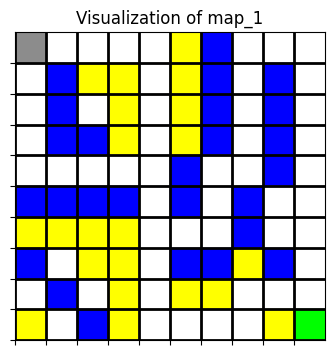

In [99]:
from grid_world import *
plot_grid_world(datas, "map_1")

In [108]:
from grid_world import GridWorld, PygameGridWorld

# check your taskbar for running pygame application GridWorld
game = PygameGridWorld()
game.main(auto_close=True, map_name="map_1", datas=datas) # auto_close will close screen automtatically at the end of game.

### Grid Search Q-Learning & SARSA sur Map 1



In [110]:
# Added by Codex - visible code cells
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pickle
from matplotlib.colors import BoundaryNorm, ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from grid_world import GridWorld, load_data


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MAP_NAME = "map_1"
NUM_EPISODES = 300
MAX_STEPS = 200



Cette fonction permet de transformer une carte issue du fichier `datas` en un environnement `GridWorld` utilisable par les agents.

Elle parcourt la grille et identifie les différentes cases :
- `1` → murs (bloqués)
- `2` → falaises (danger)
- `3` → marais (pénalité)
- `4` → objectif

Elle récupère également la position de départ, puis construit un objet `GridWorld` contenant toutes ces informations (taille, obstacles, objectif, etc.).

En résumé, elle convertit les données brutes en un environnement structuré prêt pour l’apprentissage par renforcement.

In [ ]:
def make_grid_world_from_datas(datas, map_name):
    grid = np.array(datas[map_name]["map"])
    wall_positions = []
    cliff_positions = []
    marsh_positions = []
    goal_positions = []

    for y in range(grid.shape[0]):
        for x in range(grid.shape[1]):
            cell = grid[y, x]
            if cell == 1:
                wall_positions.append((x, y))
            elif cell == 2:
                cliff_positions.append((x, y))
            elif cell == 3:
                marsh_positions.append((x, y))
            elif cell == 4:
                goal_positions.append((x, y))

    start = (datas[map_name]["start_place_x"], datas[map_name]["start_place_y"])
    return GridWorld(
        width=grid.shape[1],
        height=grid.shape[0],
        player_position=start,
        wall_positions=wall_positions,
        goal_positions=goal_positions,
        cliff_positions=cliff_positions,
        marsh_positions=marsh_positions,
    )




def get_reward(
    grid_world,
    reached_goal,
    intended_position,
    reward_final=1000,
    reward_goal=None,
    reward_default=-1,
    reward_marsh=-10,
    reward_cliff=-100,
):
    if reward_goal is not None:
        reward_final = reward_goal
    if reached_goal:
        return reward_final
    if intended_position in grid_world.cliff_positions:
        return reward_cliff
    if intended_position in grid_world.marsh_positions:
        return reward_marsh
    return reward_default


def train_one_episode(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    total_reward = 0
    trajectory = [grid_world.player_position]

    if agent.__class__.__name__ == "SarsaAgent":
        state = grid_world.player_position
        action = agent.choose_action(state)

        while not grid_world.is_game_over() and steps < max_steps:
            intended_position = get_intended_position(state, action, grid_world)
            reached_goal = grid_world.move_player(action)
            next_state = grid_world.player_position
            reward = get_reward(
                grid_world, reached_goal, intended_position, **rewards_config
            )
            next_action = agent.choose_action(next_state)

            agent.learn(state, action, reward, next_state, next_action)
            state, action = next_state, next_action
            steps += 1
            total_reward += reward
            trajectory.append(next_state)
    else:
        while not grid_world.is_game_over() and steps < max_steps:
            state = grid_world.player_position
            action = agent.choose_action(state)
            intended_position = get_intended_position(state, action, grid_world)
            reached_goal = grid_world.move_player(action)
            next_state = grid_world.player_position
            reward = get_reward(
                grid_world, reached_goal, intended_position, **rewards_config
            )

            agent.learn(state, action, reward, next_state)
            steps += 1
            total_reward += reward
            trajectory.append(next_state)

    return steps, total_reward, trajectory


### Fonctions d’entraînement et de grid search

La fonction `train_agent_on_map` permet d’entraîner un agent (Q-Learning ou SARSA) sur une carte donnée. Elle initialise l’environnement à partir de `datas`, exécute plusieurs épisodes d’apprentissage et enregistre le nombre de pas ainsi que les récompenses obtenues. Le paramètre $\epsilon$ diminue progressivement afin de réduire l’exploration au cours du temps.

La fonction `greedy_trajectory` permet de générer une trajectoire déterministe en fixant $\epsilon = 0$, ce qui permet d’observer la politique finale apprise par l’agent sans exploration.

Enfin, la fonction `run_grid_search` réalise une recherche sur plusieurs combinaisons d’hyperparamètres $(\alpha, \gamma, \epsilon)$ pour différents scénarios de récompense. Pour chaque configuration et chaque type d’agent, elle entraîne le modèle puis calcule des métriques comme le nombre moyen de pas, la récompense moyenne et leur variance.

En résumé, ces fonctions permettent d’automatiser l’entraînement, l’évaluation et la comparaison des agents sur plusieurs configurations et environnements.

In [112]:
def train_agent_on_map(
    agent_class,
    datas,
    map_name,
    alpha,
    gamma,
    epsilon,
    num_episodes=300,
    max_steps=200,
    epsilon_min=0.01,
    epsilon_decay_rate=0.01,
    rewards_config=None,
):
    grid_world = make_grid_world_from_datas(datas, map_name)
    agent = agent_class(grid_world, alpha=alpha, gamma=gamma, epsilon=epsilon)
    steps_per_episode = []
    rewards_per_episode = []

    for _ in range(num_episodes):
        grid_world.player_position = grid_world.init_player_position
        steps, total_reward, _trajectory = train_one_episode(
            agent, grid_world, max_steps, rewards_config
        )
        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)
        agent.epsilon = max(epsilon_min, agent.epsilon * np.exp(-epsilon_decay_rate))

    return {
        "agent": agent,
        "grid_world": grid_world,
        "steps": np.array(steps_per_episode),
        "rewards": np.array(rewards_per_episode),
    }


def greedy_trajectory(agent, grid_world, max_steps=200):
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0
    grid_world.player_position = grid_world.init_player_position
    trajectory = [grid_world.player_position]

    for _ in range(max_steps):
        if grid_world.is_game_over():
            break
        state = grid_world.player_position
        action = agent.choose_action(state)
        grid_world.move_player(action)
        trajectory.append(grid_world.player_position)

    agent.epsilon = old_epsilon
    return trajectory


def run_grid_search(datas, map_name, reward_scenarios, q_learning_cls, sarsa_cls):
    alphas = [0.05, 0.1, 0.5]
    gammas = [0.9, 0.99]
    epsilons = [0.9, 0.5]
    results = []

    base_params = datas[map_name]["parameters"].copy()
    base_params.update({"episodes": NUM_EPISODES, "step_limit": MAX_STEPS})

    config_id = 0
    for alpha, gamma, epsilon in itertools.product(alphas, gammas, epsilons):
        config_id += 1
        for scenario_name, scenario_rewards in reward_scenarios.items():
            rewards_config = {
                "reward_final": base_params.get("reward_final", 1000),
                "reward_default": base_params.get("reward_default", -1),
                "reward_marsh": scenario_rewards["reward_marsh"],
                "reward_cliff": scenario_rewards["reward_cliff"],
            }
            for agent_class in [q_learning_cls, sarsa_cls]:
                run = train_agent_on_map(
                    agent_class,
                    datas,
                    map_name,
                    alpha=alpha,
                    gamma=gamma,
                    epsilon=epsilon,
                    num_episodes=NUM_EPISODES,
                    max_steps=MAX_STEPS,
                    epsilon_min=base_params.get("epsilon_min", 0.01),
                    epsilon_decay_rate=base_params.get("epsilon_decay_rate", 0.01),
                    rewards_config=rewards_config,
                )
                results.append(
                    {
                        "config_id": config_id,
                        "scenario": scenario_name,
                        "agent_name": agent_class.__name__,
                        "alpha": alpha,
                        "gamma": gamma,
                        "epsilon_initial": epsilon,
                        "mean_steps": float(np.mean(run["steps"])),
                        "mean_reward": float(np.mean(run["rewards"])),
                        "var_steps": float(np.var(run["steps"])),
                        "var_reward": float(np.var(run["rewards"])),
                        "run": run,
                    }
                )
    return results


In [116]:
def plot_grid_search_results(results, scenario_name, map_name):
    rows = [r for r in results if r["scenario"] == scenario_name]
    configs = sorted({r["config_id"] for r in rows})
    labels = [f"C{c}" for c in configs]
    metrics = [
        ("mean_steps", "Steps moyens"),
        ("mean_reward", "Reward moyen"),
        ("var_reward", "Variance reward"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
    for ax, (metric, title) in zip(axes, metrics):
        for agent_name, color in [
            ("QLearningAgent", "#2563eb"),
            ("SarsaAgent", "#dc2626"),
        ]:
            values = [
                next(
                    r[metric]
                    for r in rows
                    if r["config_id"] == c and r["agent_name"] == agent_name
                )
                for c in configs
            ]
            ax.plot(labels, values, marker="o", linewidth=2, label=agent_name, color=color)
        ax.set_title(title)
        ax.set_xlabel("Configuration")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Valeur")
    axes[-1].legend()
    fig.suptitle(f"Grid search sur {map_name} - {scenario_name}")
    plt.tight_layout()
    plt.show()

    print("Correspondance des configurations :")
    for c in configs:
        row = next(r for r in rows if r["config_id"] == c)
        print(
            f"C{c}: alpha={row['alpha']}, gamma={row['gamma']}, "
            f"epsilon={row['epsilon_initial']}"
        )


def state_values(agent, grid_world):
    values = np.zeros((grid_world.height, grid_world.width), dtype=float)
    for y in range(grid_world.height):
        for x in range(grid_world.width):
            state = (x, y)
            if state in grid_world.wall_positions:
                values[y, x] = np.nan
            else:
                values[y, x] = max(agent.get_q_value(state, a) for a in agent.actions)
    return values


def plot_trajectory_and_values_3d(agent, grid_world, trajectory, title):
    grid = np.zeros((grid_world.height, grid_world.width), dtype=int)
    for x, y in grid_world.wall_positions:
        grid[y, x] = 1
    for x, y in grid_world.cliff_positions:
        grid[y, x] = 2
    for x, y in grid_world.marsh_positions:
        grid[y, x] = 3
    for x, y in grid_world.goal_positions:
        grid[y, x] = 4

    sx, sy = grid_world.init_player_position
    display_grid = grid.copy()
    display_grid[sy, sx] = 5

    colors = ["#f8fafc", "#2563eb", "#facc15", "#92400e", "#22c55e", "#9ca3af"]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)
    values = state_values(agent, grid_world)

    fig = plt.figure(figsize=(17, 7))
    ax_map = fig.add_subplot(1, 2, 1)
    ax_3d = fig.add_subplot(1, 2, 2, projection="3d")

    ax_map.imshow(display_grid, cmap=cmap, norm=norm)
    ax_map.set_xticks(np.arange(grid_world.width))
    ax_map.set_yticks(np.arange(grid_world.height))
    ax_map.set_xticks(np.arange(-0.5, grid_world.width, 1), minor=True)
    ax_map.set_yticks(np.arange(-0.5, grid_world.height, 1), minor=True)
    ax_map.grid(which="minor", color="#111827", linewidth=1.0)
    ax_map.tick_params(which="minor", bottom=False, left=False)
    ax_map.set_title(f"Trajectoire finale - {title}")

    if trajectory:
        xs = [pos[0] for pos in trajectory]
        ys = [pos[1] for pos in trajectory]
        ax_map.plot(xs, ys, color="#ef4444", linewidth=2.5, marker="o", markersize=4)

    ax_map.text(sx, sy, "S", ha="center", va="center", fontweight="bold")
    for gx, gy in grid_world.goal_positions:
        ax_map.text(gx, gy, "G", ha="center", va="center", fontweight="bold")

    xs = []
    ys = []
    zs = []
    dx = []
    dy = []
    dz = []
    bar_colors = []

    for y in range(grid_world.height):
        for x in range(grid_world.width):
            if (x, y) in grid_world.wall_positions or np.isnan(values[y, x]):
                continue
            xs.append(x - 0.4)
            ys.append(y - 0.4)
            zs.append(0)
            dx.append(0.8)
            dy.append(0.8)
            dz.append(values[y, x])
            bar_colors.append(colors[grid[y, x]] if grid[y, x] < len(colors) else colors[0])

    ax_3d.bar3d(xs, ys, zs, dx, dy, dz, shade=True, color=bar_colors, alpha=0.9)
    ax_3d.set_title(f"Valeur V(s)=max_a Q(s,a) - {title}")
    ax_3d.set_xlabel("x")
    ax_3d.set_ylabel("y")
    ax_3d.set_zlabel("V(s)")
    ax_3d.view_init(elev=30, azim=-55)

    plt.tight_layout()
    plt.show()


### Protocole expérimental et analyse des configurations

La fonction `run_experiment` automatise l’étude en définissant deux scénarios :
- **pénalité modérée** : environnement peu contraignant  
- **risque fort** : fortes pénalités (falaises)

Un **grid search** est effectué sur $(\alpha, \gamma, \epsilon)$ pour Q-Learning et SARSA. Les performances sont évaluées via le nombre moyen d’étapes, la récompense moyenne et la variance. La meilleure configuration est ensuite visualisée (trajectoire greedy + surface 3D des valeurs).


#### Cas simple

Dans ce cas, une configuration typique est :
$
\alpha \approx 0.1,\quad \gamma \in \{0.9, 0.99\},\quad \epsilon \approx 0.9
$

L’exploration étant peu coûteuse, l’agent converge rapidement vers une politique proche de l’optimal. Les récompenses sont élevées et la variance reste faible. Le biais lié à
$
\max_a Q(s,a)
$
a peu d’impact, car les erreurs sont peu pénalisées. Q-Learning est donc efficace et proche de SARSA.
#### Cas risqué

La meilleure configuration observée est :
$
\alpha = 0.5,\quad \gamma = 0.99,\quad \epsilon = 0.5$. L’apprentissage est rapide et les performances élevées, mais la variance importante révèle une instabilité. Le terme
$
\max_a Q(s,a)
$ introduit un biais optimiste (*overestimation bias*), conduisant à des décisions parfois risquées. Les trajectoires montrent des chemins efficaces mais proches des zones dangereuses. La surface 3D confirme une propagation rapide des valeurs, au prix d’une moindre robustesse.

 

#### Convergence

On observe une diminution des étapes et une augmentation des récompenses, signe d’une convergence globale. Q-Learning converge rapidement grâce à :
$
\max_a Q(s,a)
$
mais avec une variance plus élevée. En environnement risqué, cette instabilité est plus marquée. À l’inverse, en pénalité modérée, la convergence est plus stable.
La décroissance de $\epsilon$ permet le passage progressif de l’exploration à l’exploitation.


Ainsi le Q-Learning est rapide et performant, mais plus instable en environnement risqué. SARSA, en intégrant l’exploration, offre des politiques plus robustes. Le choix dépend donc du compromis entre performance et sécurité.

loaded maps : dict_keys(['map_1', 'map_2', 'map_7', 'map_8', 'map_12', 'map_16'])


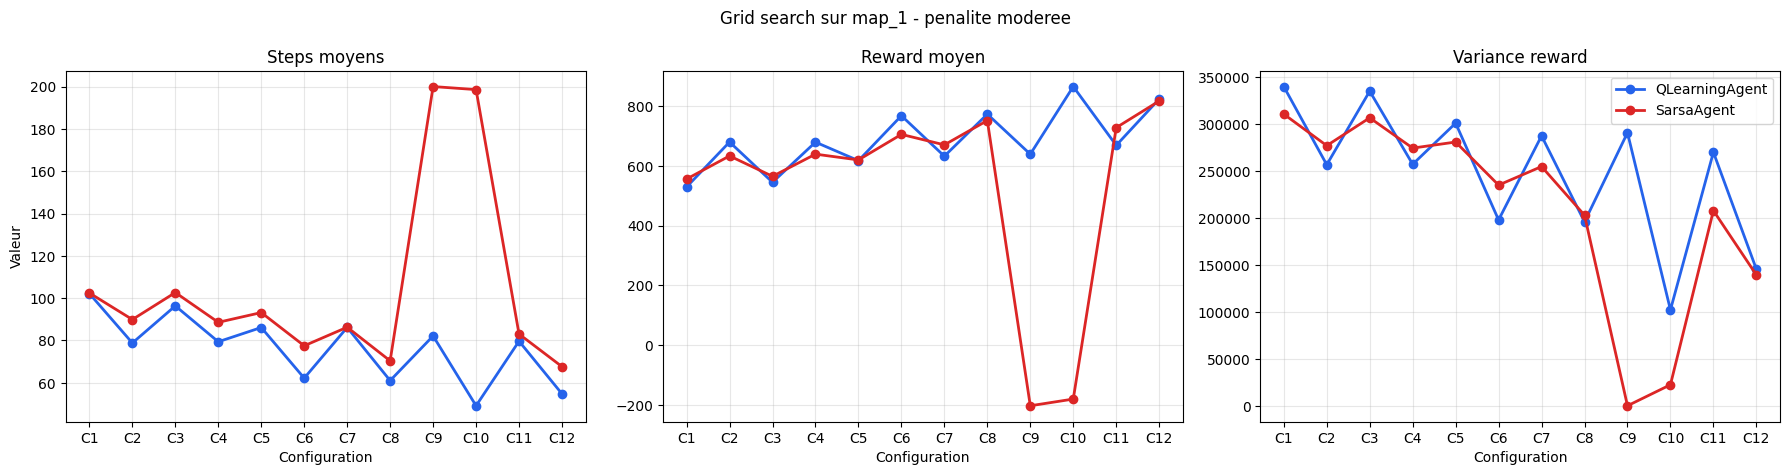

Correspondance des configurations :
C1: alpha=0.05, gamma=0.9, epsilon=0.9
C2: alpha=0.05, gamma=0.9, epsilon=0.5
C3: alpha=0.05, gamma=0.99, epsilon=0.9
C4: alpha=0.05, gamma=0.99, epsilon=0.5
C5: alpha=0.1, gamma=0.9, epsilon=0.9
C6: alpha=0.1, gamma=0.9, epsilon=0.5
C7: alpha=0.1, gamma=0.99, epsilon=0.9
C8: alpha=0.1, gamma=0.99, epsilon=0.5
C9: alpha=0.5, gamma=0.9, epsilon=0.9
C10: alpha=0.5, gamma=0.9, epsilon=0.5
C11: alpha=0.5, gamma=0.99, epsilon=0.9
C12: alpha=0.5, gamma=0.99, epsilon=0.5


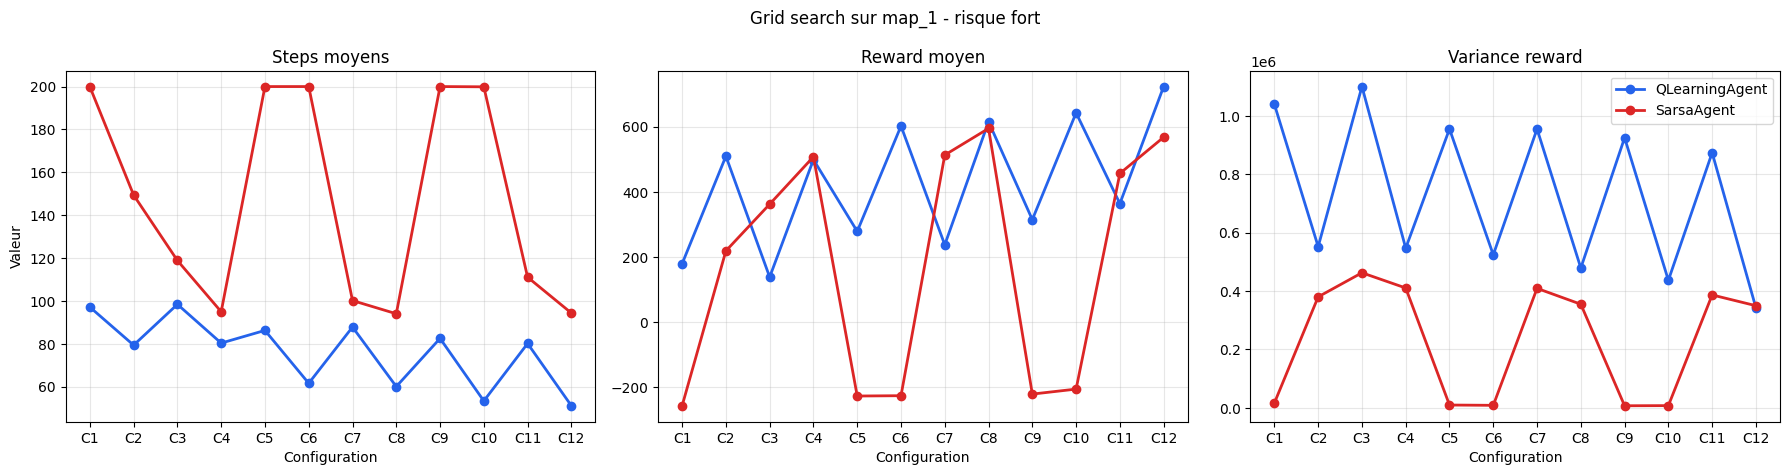

Correspondance des configurations :
C1: alpha=0.05, gamma=0.9, epsilon=0.9
C2: alpha=0.05, gamma=0.9, epsilon=0.5
C3: alpha=0.05, gamma=0.99, epsilon=0.9
C4: alpha=0.05, gamma=0.99, epsilon=0.5
C5: alpha=0.1, gamma=0.9, epsilon=0.9
C6: alpha=0.1, gamma=0.9, epsilon=0.5
C7: alpha=0.1, gamma=0.99, epsilon=0.9
C8: alpha=0.1, gamma=0.99, epsilon=0.5
C9: alpha=0.5, gamma=0.9, epsilon=0.9
C10: alpha=0.5, gamma=0.9, epsilon=0.5
C11: alpha=0.5, gamma=0.99, epsilon=0.9
C12: alpha=0.5, gamma=0.99, epsilon=0.5


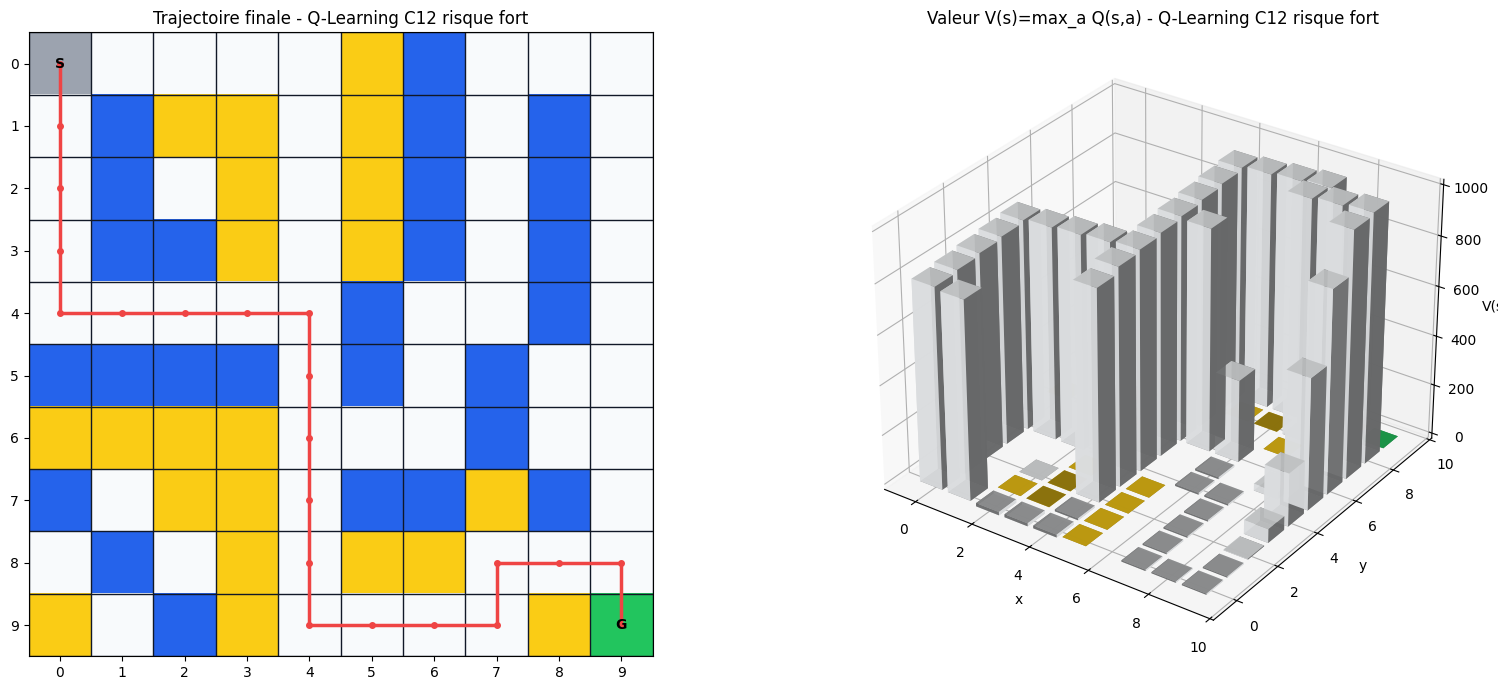

Meilleure config Q-Learning risque fort: {'config_id': 12, 'alpha': 0.5, 'gamma': 0.99, 'epsilon_initial': 0.5, 'mean_steps': 51.04, 'mean_reward': 722.74, 'var_reward': 342118.84}


In [114]:
def run_experiment(q_learning_cls, sarsa_cls):
    datas = load_data()
    reward_scenarios = {
        "penalite moderee": {"reward_cliff": -10, "reward_marsh": -10},
        "risque fort": {"reward_cliff": -100, "reward_marsh": -10},
    }

    results = run_grid_search(
        datas,
        MAP_NAME,
        reward_scenarios,
        q_learning_cls=q_learning_cls,
        sarsa_cls=sarsa_cls,
    )

    plot_grid_search_results(results, "penalite moderee", MAP_NAME)
    plot_grid_search_results(results, "risque fort", MAP_NAME)

    best_q_risk = max(
        [
            r
            for r in results
            if r["scenario"] == "risque fort" and r["agent_name"] == "QLearningAgent"
        ],
        key=lambda r: r["mean_reward"],
    )

    best_run = best_q_risk["run"]
    final_trajectory = greedy_trajectory(
        best_run["agent"], best_run["grid_world"], max_steps=MAX_STEPS
    )
    plot_trajectory_and_values_3d(
        best_run["agent"],
        best_run["grid_world"],
        final_trajectory,
        title=f"Q-Learning C{best_q_risk['config_id']} risque fort",
    )

    print(
        "Meilleure config Q-Learning risque fort:",
        {
            "config_id": best_q_risk["config_id"],
            "alpha": best_q_risk["alpha"],
            "gamma": best_q_risk["gamma"],
            "epsilon_initial": best_q_risk["epsilon_initial"],
            "mean_steps": round(best_q_risk["mean_steps"], 2),
            "mean_reward": round(best_q_risk["mean_reward"], 2),
            "var_reward": round(best_q_risk["var_reward"], 2),
        },
    )

run_experiment(QLearningAgent, SarsaAgent)


### Analyse des résultats par carte

Le cas simple correspond à des pénalités modérées, par exemple falaise = -10. Le cas risqué correspond à des pénalités fortes, par exemple falaise = -100. Les deux cas permettent de tester si l’agent privilégie un chemin court ou un chemin plus sûr.

| Map     | Environnement        | Cas        | Q-Learning (tendance)             | SARSA (tendance)                 | Interprétation |
|---------|---------------------|------------|----------------------------------|----------------------------------|----------------|
| map_1   | Falaises            | Risqué     | Rapide mais très instable (var ↑) | Plus lent, reward ↑, stable      | SARSA évite le risque, QL surestime |
| map_1   | Falaises            | Simple     | Similaire                         | Similaire                         | Impact du risque clé |
| map_2   | Falaises            | Risqué     | Plus rapide                       | Plus stable                       | Environnement moins piégeux |
| map_2   | Falaises            | Simple     | Similaire                         | Similaire                         | Peu de différence |
| map_7   | Marais              | Risqué     | Légèrement meilleur               | Bon et stable                     | Peu de risque extrême |
| map_7   | Marais              | Simple     | Échec (reward négatif)            | Très performant                   | QL instable en bruit |
| map_8   | Marais              | Risqué     | Correct mais instable             | Stable                            | SARSA plus robuste |
| map_8   | Marais              | Simple     | Mauvaise convergence              | Stable                            | Exploration mal gérée |
| map_12  | Marais + Falaises   | Risqué     | Bon en moyenne, var élevée        | Moins performant mais stable      | Trade-off perf/stabilité |
| map_12  | Mixte               | Simple     | Légère avance                     | Proche                            | Différence faible |
| map_16  | Falaise directe     | Risqué     | Rapide mais risqué                | Plus prudent, reward ↑            | SARSA anticipe mieux |
| map_16  | Falaises            | Simple     | Similaire                         | Similaire                         | Convergence proche |

### Lecture globale

- Q-Learning → rapide, mais sensible au risque et à la variance  
- SARSA → plus lent, mais plus stable et robuste  
- Les écarts apparaissent surtout en présence de **falaises** ou de **bruit**



### Justification des hyperparamètres

| Paramètre | Valeur utilisée | Rôle | Impact observé |
|----------|---------------|------|----------------|
| ε        | 0.9           | Exploration | Forte exploration → instabilité en environnement risqué |
| α        | 0.1           | Apprentissage | Bon compromis, limite les oscillations |
| γ        | 0.99          | Horizon long terme | Favorise l’objectif mais amplifie les erreurs |

#### Interactions clés

- **ε élevé + falaises → variance élevée**  
- **Q-Learning + max(Q) → biais optimiste → instabilité**  
- **γ élevé → propagation des erreurs**  

→ explique pourquoi :
- Q-Learning = performant mais instable  
- SARSA = robuste mais plus lent  


### Conclusion globale

- **Q-Learning** : rapide et performant en moyenne, mais instable en environnement risqué  
- **SARSA** : plus lent, mais plus robuste  

Les différences sont principalement visibles dans les environnements comportant des falaises, où SARSA adopte des stratégies plus sûres.

In [115]:

from map1_qlearning_sarsa_gridsearch import FULL_GRID, LIGHT_GRID, print_report_ready_summary, run_map_pipeline, run_selected_maps

# 1) Une map cle avec plots complets
# results_map16, best_map16 = run_map_pipeline(QLearningAgent, SarsaAgent, map_name="map_16", grid_config=FULL_GRID, show_plots=True, show_3d=True)

# 2) Toutes les maps avec la meme pipeline, sans les graphiques pour aller plus vite
all_results, all_best_rows = run_selected_maps(
    QLearningAgent,
    SarsaAgent,
    map_names=["map_1", "map_2", "map_7", "map_8", "map_12", "map_16"],
    grid_config=LIGHT_GRID,
    show_plots=False,
)

print_report_ready_summary(all_best_rows)


loaded maps : dict_keys(['map_1', 'map_2', 'map_7', 'map_8', 'map_12', 'map_16'])

===== Pipeline sur map_1 =====
Marais: False | Falaises: True
loaded maps : dict_keys(['map_1', 'map_2', 'map_7', 'map_8', 'map_12', 'map_16'])

Resume des meilleures configurations pour map_1
------------------------------------------------------------------------------------------
Scenario             Agent            Cfg  alpha  gamma  eps   steps      reward     var_r     
------------------------------------------------------------------------------------------
cas risque           QLearningAgent   C3   0.1    0.9    0.9   86.21      234.62     1020259.75
cas risque           SarsaAgent       C4   0.1    0.99   0.9   95.29      557.89     370448.72 
cas simple           QLearningAgent   C4   0.1    0.99   0.9   86.27      667.82     247977.98 
cas simple           SarsaAgent       C3   0.1    0.9    0.9   85.61      665.14     250721.14 

===== Pipeline sur map_2 =====
Marais: False | Falaises: True

### **Analyse de la variance et des hyperparamètres**


Une variance élevée signifie que les performances changent beaucoup d’un épisode à l’autre : l’agent peut parfois trouver un bon chemin, mais aussi tomber fréquemment dans des zones pénalisantes.
La variance des récompenses est particulièrement élevée pour Q-Learning dans les environnements risqués. Cela s’explique par un epsilon élevé, qui augmente l’exploration et donc les actions dangereuses, combiné au biais optimiste du terme $maxₐ Q(s′,a)$, qui amplifie les estimations incertaines. Cette combinaison conduit à des comportements instables.

À l’inverse, SARSA présente une variance plus faible car il prend en compte l’action réellement exécutée, ce qui rend l’apprentissage plus prudent et stable. 

Les hyperparamètres influencent directement cette variance : un alpha élevé accentue la sensibilité aux nouvelles observations, un gamma proche de 1 propage davantage les erreurs, et un epsilon élevé augmente la variabilité. Ces effets expliquent que certaines configurations performantes en moyenne restent instables.

### **Limites expérimentales et critique des résultats**

Les résultats sont cohérents mais présentent plusieurs limites. La convergence observée ne garantit pas l’optimalité : l’agent peut converger vers une solution sous-optimale si l’exploration devient insuffisante, avec un risque de minimum local.

Les expériences ne testent pas la robustesse, car elles reposent sur une seule seed. Or, les performances peuvent varier selon les trajectoires. Il serait nécessaire de répéter les runs et moyenner les résultats.


Aucune baseline (agent aléatoire ou politique fixe) n’est utilisée, ce qui limite l’évaluation du gain réel apporté par les algorithmes.
Enfin, certains choix techniques sont peu justifiés : un epsilon decay rapide réduit trop vite l’exploration, favorisant une convergence prématurée, et l’initialisation de la Q-table à zéro introduit un biais initial. Des alternatives (décroissance plus progressive, initialisation optimiste) pourraient améliorer les résultats.
Ces limites suggèrent que des expérimentations supplémentaires sont nécessaires pour consolider les conclusions.

## Réponse à la consigne

Nous avons :
- initialisé plusieurs Grid Worlds ;
- implémenté Q-Learning et SARSA ;
- entraîné les agents sur plusieurs cartes ;
- visualisé les politiques apprises ;
- testé plusieurs valeurs de α, γ et ε ;
- comparé les performances en steps, rewards et variance.

# Conclusion 
Les résultats expérimentaux montrent que Q-Learning et SARSA convergent tous deux vers des politiques efficaces, mais présentent des comportements différents. Q-Learning converge plus rapidement grâce à son caractère off-policy, mais au prix d’une plus grande variance et d’un risque de surestimation, ce qui peut conduire à des stratégies dangereuses dans des environnements risqués.
À l’inverse, SARSA, en intégrant les actions réellement exécutées, adopte un comportement plus prudent et stable. Cette différence est particulièrement visible dans les environnements comportant des falaises, où SARSA obtient de meilleures performances en termes de récompense.
Ainsi, le choix de l’algorithme dépend du compromis recherché entre performance et robustesse.

### Ouverture : 
Ce travail peut être mis en perspective avec les algorithmes de colonies de fourmis (Ant Colony Optimization), que nous avons également étudiés. Nous avons observé qu’il existe un lien conceptuel fort entre ces approches : dans les deux cas, la recherche d’une solution optimale repose sur un compromis entre exploration et exploitation. Toutefois, là où Q-Learning et SARSA s’appuient sur un apprentissage individuel basé sur une fonction de valeur, les algorithmes de colonies de fourmis reposent sur un mécanisme d’intelligence collective via les phéromones. Cette analogie met en évidence différentes manières de résoudre un même type de problème d’optimisation séquentielle.